In [46]:
#data handiling
import pandas as pd
import numpy as np




In [47]:
#data visualisation
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

In [67]:
#text preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
import re
import string

In [49]:
#models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [86]:
#evaluation
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report, ConfusionMatrixDisplay
import joblib


In [51]:
#loading dataset
df=pd.read_csv('/content/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [52]:
#df info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [53]:
#missing values
df.isnull().sum()

,0
review,0
sentiment,0


In [54]:
#statistical summary
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [55]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


/tmp/ipykernel_2598/2220685285.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment',data=df,palette='coolwarm')


<Axes: xlabel='sentiment', ylabel='count'>

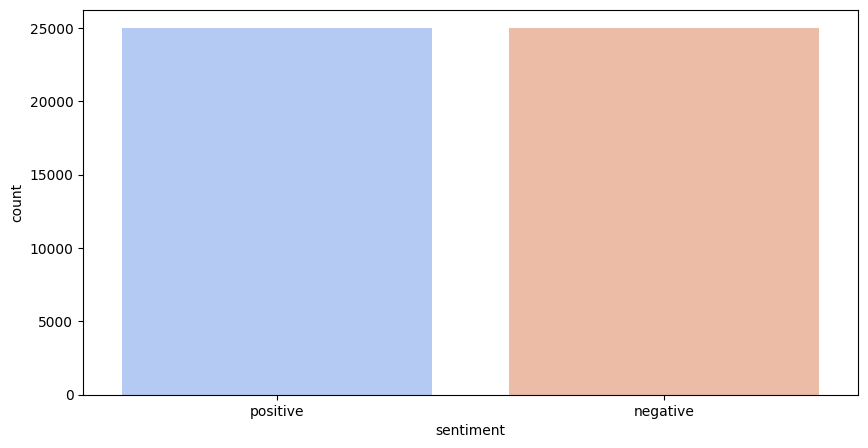

In [56]:
#EDA
plt.figure(figsize=(10,5))
sns.countplot(x='sentiment',data=df,palette='coolwarm')

In [57]:
#data preprocessing
# removing symbols etc
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))
text=df['review']
def clean_text(text):
    text = text.lower()                                          # lowercase
    text = re.sub(r'\[.*?\]', '', text)                         # remove brackets
    text = re.sub(r'https?://\S+|www\.\S+', '', text)           # remove URLs
    text = re.sub(r'<.*?>+', '', text)                          # remove HTML tags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # remove punctuation
    text = re.sub(r'\n', '', text)                              # remove newlines
    text = re.sub(r'\w*\d\w*', '', text)                        # remove words with numbers
    text = re.sub(r'[^a-z\s]', '', text)                        # keep only letters
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

# Apply cleaning
df['cleaned_review'] = df['review'].apply(clean_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [58]:
df['review'].head()

,review
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is..."


In [60]:
df['cleaned_review'].head()

,cleaned_review
0,one reviewers mentioned watching oz episode yo...
1,wonderful little production filming technique ...
2,thought wonderful way spend time hot summer we...
3,basically theres family little boy jake thinks...
4,petter matteis love time money visually stunni...


In [72]:
# Label Encoding + Train/Test Split

df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")

Train size : 40,000
Test size  : 10,000


In [73]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

In [76]:
#logistical regression
lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
lr_model.fit(X_train_tfidf, y_train)

lr_preds = lr_model.predict(X_test_tfidf)
lr_acc   = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Accuracy: {lr_acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['Negative', 'Positive']))

Logistic Regression Accuracy: 89.86%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [77]:
#Naive Bayes
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

nb_preds = nb_model.predict(X_test_tfidf)
nb_acc   = accuracy_score(y_test, nb_preds)

print(f"Naive Bayes Accuracy: {nb_acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, nb_preds, target_names=['Negative', 'Positive']))

Naive Bayes Accuracy: 88.28%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      5000
    Positive       0.88      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [78]:
#SVM
svm_model=LinearSVC(C=1.0,max_iter=10000)
svm_model.fit(X_train_tfidf,y_train)

svm_preds=svm_model.predict(X_test_tfidf)
svm_acc=accuracy_score(y_test,svm_preds)

print(f"SVM Accuracy: {svm_acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, svm_preds, target_names=['Negative', 'Positive']))

SVM Accuracy: 90.15%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90      5000
    Positive       0.90      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



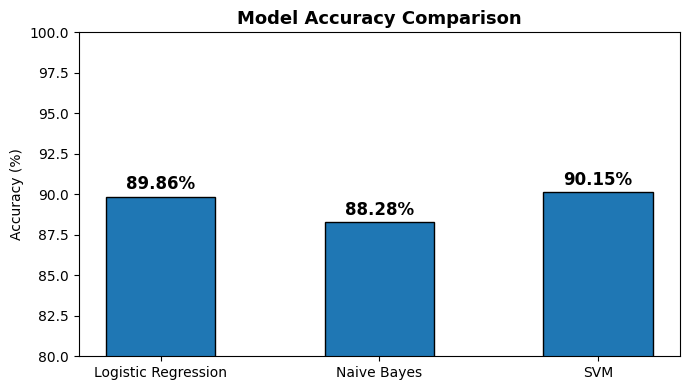

In [94]:
models      = ['Logistic Regression', 'Naive Bayes','SVM']
accuracies  = [lr_acc * 100, nb_acc * 100,svm_acc* 100]

plt.figure(figsize=(7, 4))
bars = plt.bar(models, accuracies , edgecolor='black', width=0.5)
plt.ylim(80, 100)
plt.title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [97]:
#saving best model
import pickle

pickle.dump(svm_model, open("model.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))